# What Factors Influence College Graduate Earnings?
**Author:** Aiden Akbarov  
**Course:** STA 4164 – Statistical Methods III | University of Central Florida  
**Date:** May 2026  

---

This notebook replicates the R analysis in Python using pandas, numpy, seaborn, and scikit-learn.

**Research Questions:**
- Do majors with higher female representation earn less?
- Does unemployment rate or job type predict earnings?
- Which broad field of study is the strongest predictor?

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

---
## 2. Data Preparation

In [2]:
df = pd.read_csv('../data/recent-grads.csv')

# Drop rows with missing values (Food Science major)
df = df.dropna()

print(f'Dataset shape: {df.shape}')
print(f'\nResponse variable (Median) summary:')
print(df['Median'].describe())

Dataset shape: (172, 21)

Response variable (Median) summary:
count       172.000000
mean      40076.744186
std       11461.388773
min       22000.000000
25%       33000.000000
50%       36000.000000
75%       45000.000000
max      110000.000000
Name: Median, dtype: float64


---
## 3. Exploratory Data Analysis

### 3.1 Distribution of Median Earnings

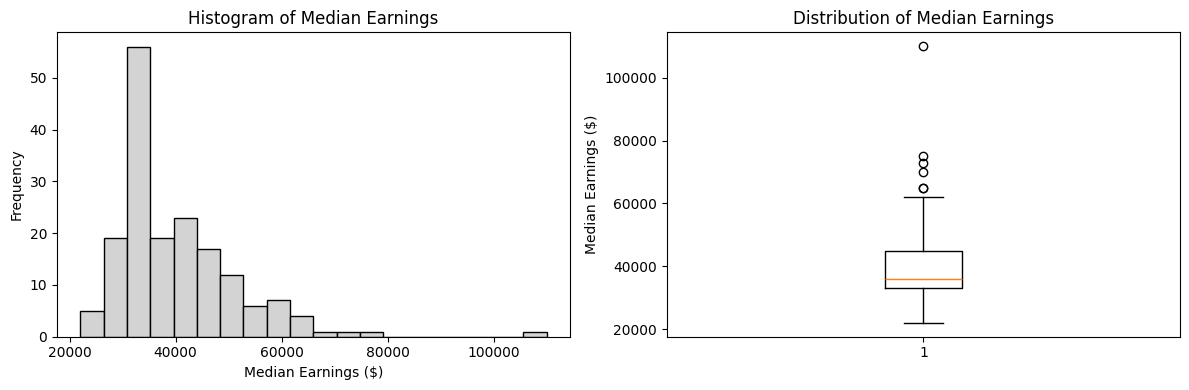


The distribution is right-skewed — most majors earn between $30k-$45k.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['Median'], bins=20, color='lightgray', edgecolor='black')
axes[0].set_title('Histogram of Median Earnings')
axes[0].set_xlabel('Median Earnings ($)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['Median'])
axes[1].set_title('Distribution of Median Earnings')
axes[1].set_ylabel('Median Earnings ($)')

plt.tight_layout()
plt.show()

print('\nThe distribution is right-skewed — most majors earn between $30k-$45k.')

### 3.2 Earnings by Major Category

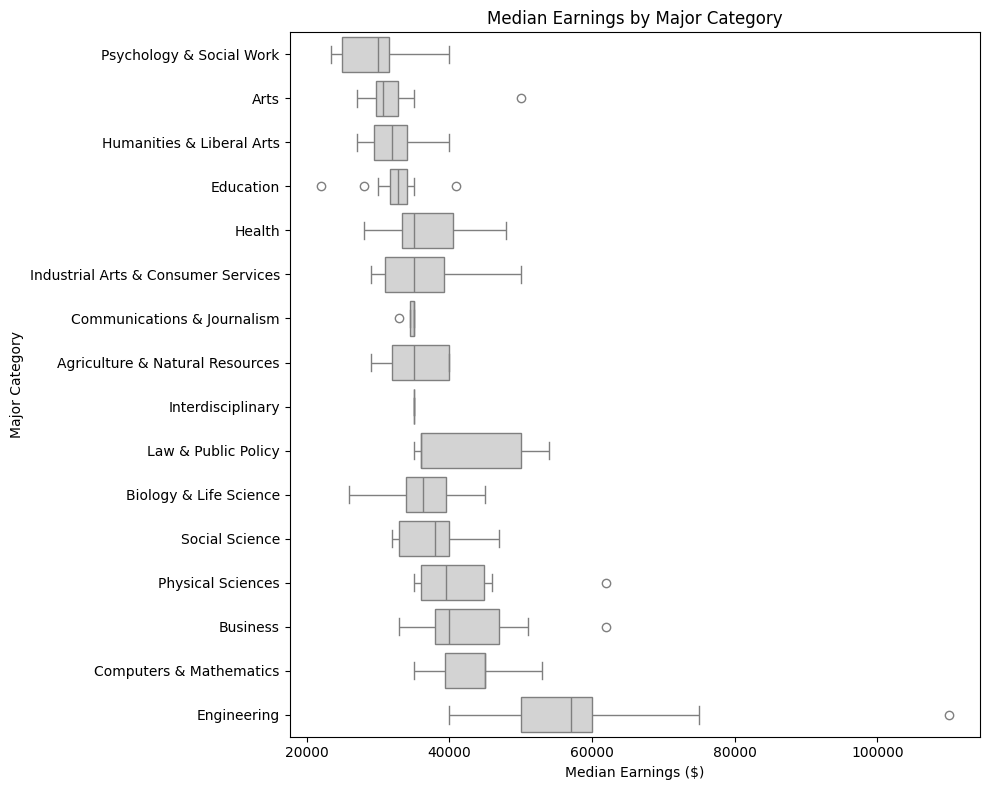

In [4]:
# Sort categories by median earnings
order = df.groupby('Major_category')['Median'].median().sort_values().index

plt.figure(figsize=(10, 8))
sns.boxplot(data=df, y='Major_category', x='Median', order=order, color='lightgray')
plt.title('Median Earnings by Major Category')
plt.xlabel('Median Earnings ($)')
plt.ylabel('Major Category')
plt.tight_layout()
plt.show()

### 3.3 Relationships with Predictor Variables

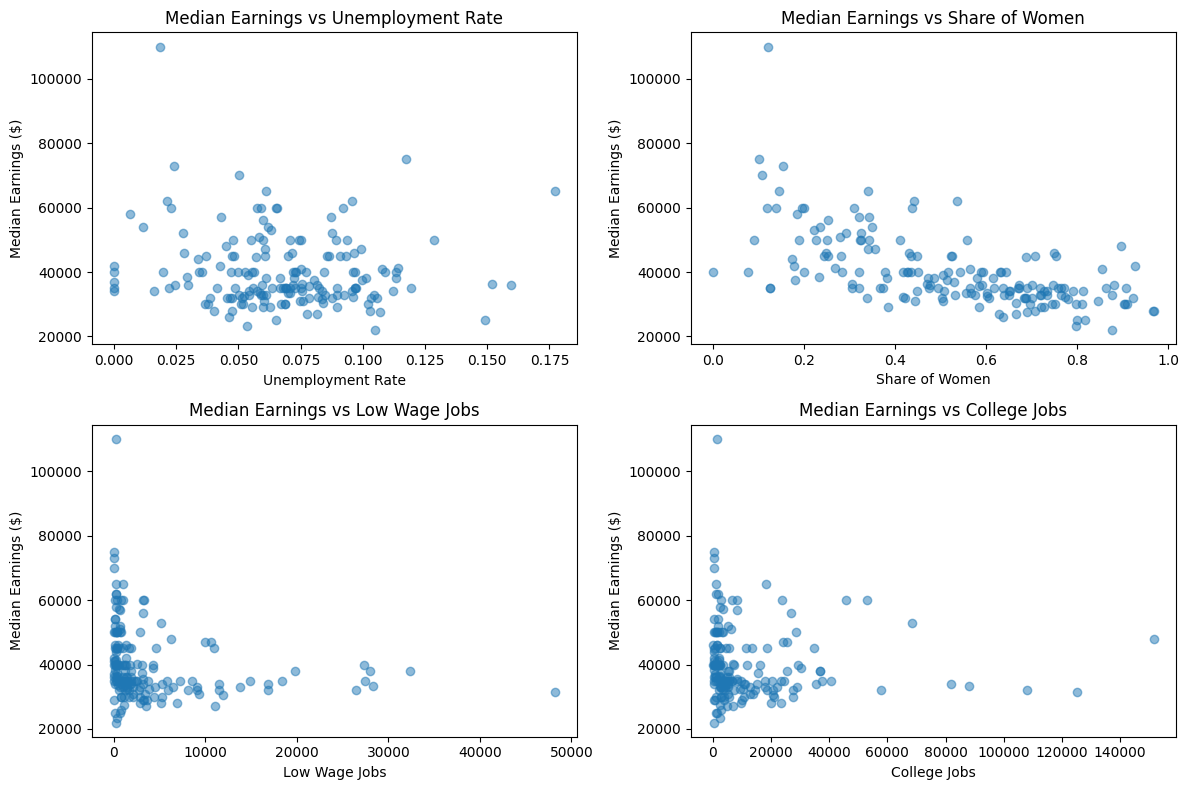

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

predictors = [
    ('Unemployment_rate', 'Unemployment Rate'),
    ('ShareWomen',        'Share of Women'),
    ('Low_wage_jobs',     'Low Wage Jobs'),
    ('College_jobs',      'College Jobs')
]

for ax, (col, label) in zip(axes.flatten(), predictors):
    ax.scatter(df[col], df['Median'], alpha=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Median Earnings ($)')
    ax.set_title(f'Median Earnings vs {label}')

plt.tight_layout()
plt.show()

### 3.4 Correlation Matrix

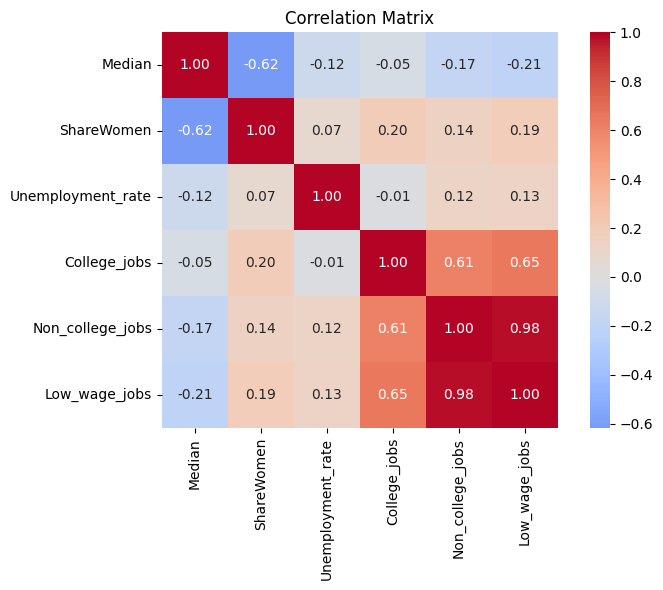


Note: Non_college_jobs and Low_wage_jobs are highly correlated (r=0.98)
This informed our variable selection — both cannot be included together.


In [6]:
num_cols = ['Median', 'ShareWomen', 'Unemployment_rate',
            'College_jobs', 'Non_college_jobs', 'Low_wage_jobs']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nNote: Non_college_jobs and Low_wage_jobs are highly correlated (r=0.98)')
print('This informed our variable selection — both cannot be included together.')

---
## 4. Model Building

### 4.1 Train / Test Split (70/30)

In [7]:
# One-hot encode Major_category (drop first to avoid dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['Major_category'], drop_first=True)

# Define features based on final R model: ShareWomen + Major_category
feature_cols = ['ShareWomen'] + [c for c in df_encoded.columns if 'Major_category_' in c]

X = df_encoded[feature_cols]
y = df_encoded['Median']

# Match R's set.seed(4164) as closely as possible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=4164
)

print(f'Training set: {X_train.shape[0]} observations')
print(f'Testing set:  {X_test.shape[0]} observations')

Training set: 120 observations
Testing set:  52 observations


### 4.2 Final Model (replicating R's backward AIC result)

In [8]:
# Convert booleans to integers (fix for statsmodels)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Add constant for intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit OLS model using statsmodels for full summary output
final_model = sm.OLS(y_train, X_train_sm).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Median   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     10.04
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.04e-14
Time:                        03:55:01   Log-Likelihood:                -1240.6
No. Observations:                 120   AIC:                             2515.
Df Residuals:                     103   BIC:                             2563.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

---
## 5. Model Diagnostics

### 5.1 Multicollinearity — VIF

In [9]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
print('\nAll VIF values below 5 — no significant multicollinearity')

                                           Feature       VIF
                                        ShareWomen 13.631200
                          Major_category_Education  3.006916
                             Major_category_Health  2.787044
           Major_category_Psychology & Social Work  2.504742
             Major_category_Biology & Life Science  2.472818
          Major_category_Humanities & Liberal Arts  2.299676
                               Major_category_Arts  1.879442
                     Major_category_Social Science  1.737219
                           Major_category_Business  1.715779
                  Major_category_Physical Sciences  1.631614
        Major_category_Communications & Journalism  1.522729
                        Major_category_Engineering  1.419727
            Major_category_Computers & Mathematics  1.229598
                  Major_category_Interdisciplinary  1.211086
                Major_category_Law & Public Policy  1.166968
Major_category_Industria

### 5.2 Residuals vs Fitted

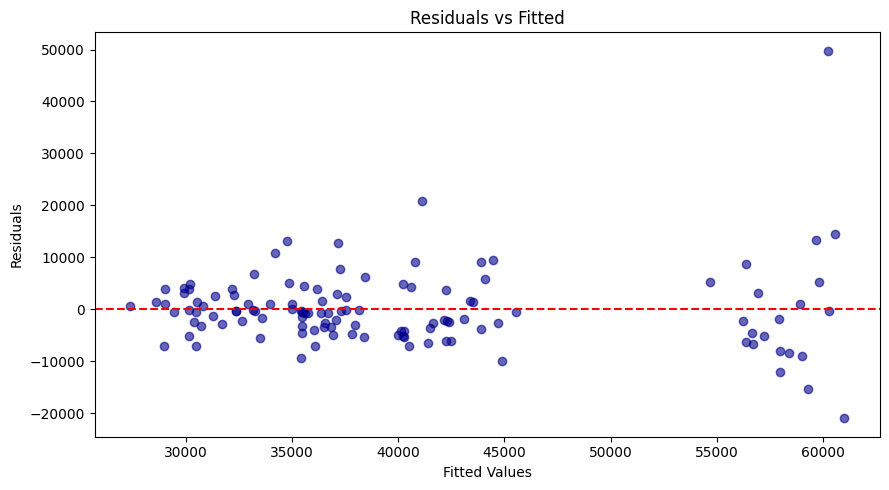

In [10]:
fitted    = final_model.fittedvalues
residuals = final_model.resid

plt.figure(figsize=(9, 5))
plt.scatter(fitted, residuals, alpha=0.6, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

### 5.3 Normality of Residuals

Shapiro-Wilk Test (original model): W=0.8182, p=0.000000
Shapiro-Wilk Test (log model):      W=0.9635, p=0.002424



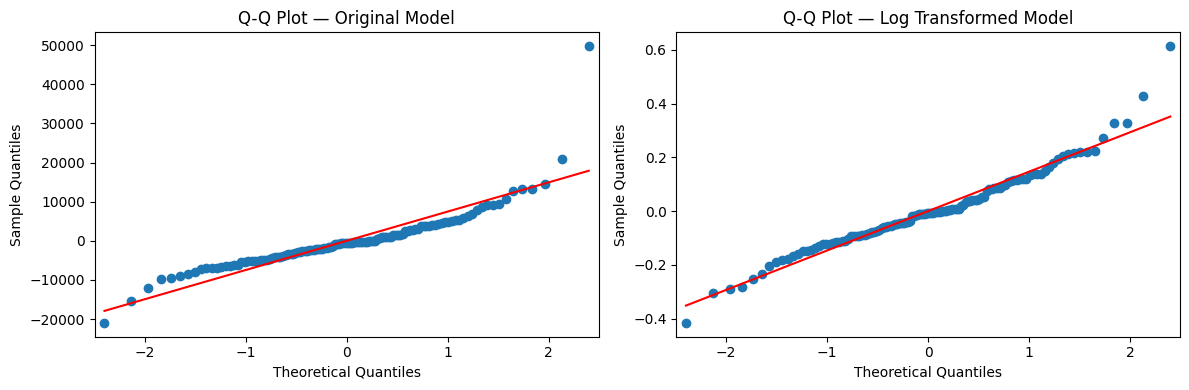

In [11]:
from scipy import stats

# Shapiro-Wilk test
stat, p = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test (original model): W={stat:.4f}, p={p:.6f}')

# Log-transformed model
y_train_log = np.log(y_train)
log_model   = sm.OLS(y_train_log, X_train_sm).fit()
stat_log, p_log = stats.shapiro(log_model.resid)
print(f'Shapiro-Wilk Test (log model):      W={stat_log:.4f}, p={p_log:.6f}\n')

# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.qqplot(residuals, line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot — Original Model')
sm.qqplot(log_model.resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot — Log Transformed Model')
plt.tight_layout()
plt.show()

### 5.4 Cook's Distance — Influential Observations

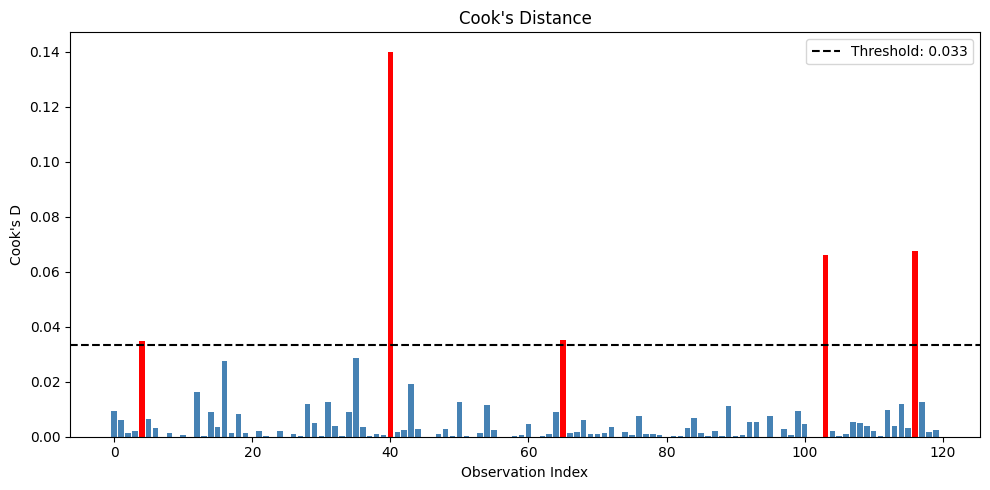


Influential observations: [  4  40  65 103 116]
These represent legitimate high-earning Engineering majors and were retained.


In [12]:
influence  = final_model.get_influence()
cooks_d, _ = influence.cooks_distance
threshold  = 4 / len(X_train)

plt.figure(figsize=(10, 5))
colors = ['red' if c > threshold else 'steelblue' for c in cooks_d]
plt.bar(range(len(cooks_d)), cooks_d, color=colors)
plt.axhline(y=threshold, color='black', linestyle='--',
            label=f'Threshold: {threshold:.3f}')
plt.title("Cook's Distance")
plt.xlabel('Observation Index')
plt.ylabel("Cook's D")
plt.legend()
plt.tight_layout()
plt.show()

influential = np.where(cooks_d > threshold)[0]
print(f'\nInfluential observations: {influential}')
print('These represent legitimate high-earning Engineering majors and were retained.')

---
## 6. Model Validation

In [13]:
# Predictions on test set
test_preds = final_model.predict(X_test_sm)

# Performance metrics
test_mae  = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
null_mae  = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
improvement = (1 - test_mae / null_mae) * 100

print('--- Validation Results ---')
print(f'Testing MAE:          ${test_mae:,.2f}')
print(f'Baseline (Mean) MAE:  ${null_mae:,.2f}')
print(f'Improvement:          {improvement:.1f}%')
print(f'Testing RMSE:         ${test_rmse:,.2f}')

--- Validation Results ---
Testing MAE:          $4,510.48
Baseline (Mean) MAE:  $7,799.71
Improvement:          42.2%
Testing RMSE:         $6,273.45


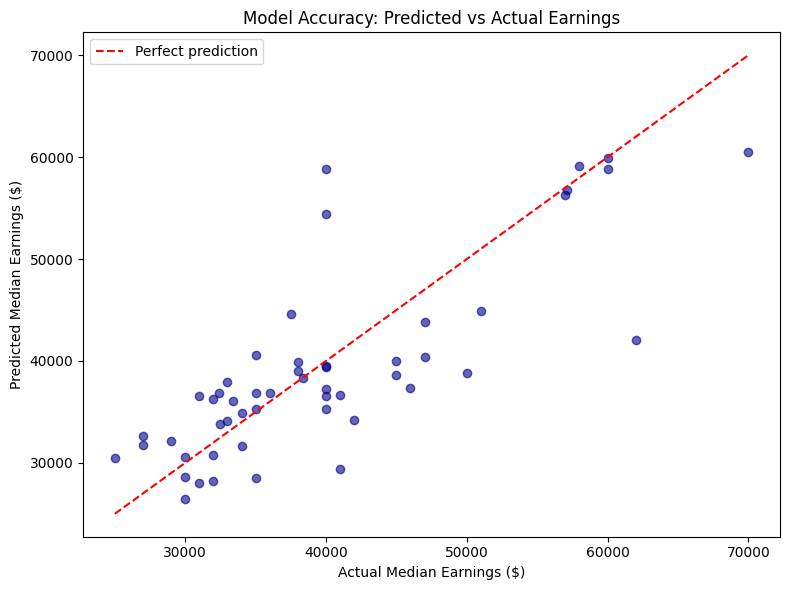

In [14]:
# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.6, color='darkblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect prediction')
plt.title(f'Model Accuracy: Predicted vs Actual Earnings')
plt.xlabel('Actual Median Earnings ($)')
plt.ylabel('Predicted Median Earnings ($)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Results Summary

| Metric | Value |
|--------|-------|
| Dataset size | 172 college majors |
| Model type | Multiple Linear Regression |
| Adjusted R² | ~0.545 |
| Testing MAE | 4,510 |
| Baseline MAE | 7,800 |
| Improvement | ~42% |

**Key findings:**
- Engineering graduates earn ~\$20,400 more than the Agriculture baseline
- For every 10% increase in female representation, predicted median salary drops ~\$1,700
- The model explains **55% of variance** in median earnings
- Job type and unemployment rate were **not significant** predictors after backward elimination

---
## 8. References

- Jun, E. (n.d.). *data_college_income* [Data set]. GitHub. https://github.com/emjun/data_college_income  
- R Core Team. (2024). *R: A language and environment for statistical computing.* https://www.R-project.org/  
- Wickham, H. (2016). *ggplot2: Elegant Graphics for Data Analysis.* Springer-Verlag.

*Note: Results differ slightly from R analysis due to differences
in random number generation between languages. Core findings are consistent.*